# 🛒 Online Retail Sales Analysis using Python

### 📌 Project Overview
This project analyzes the **Online Retail Dataset (Kaggle)** using **Python, Pandas, NumPy, and Matplotlib** to uncover sales trends, customer purchasing behavior, product performance, country-wise revenue, and business insights. The analysis includes data cleaning, exploratory data analysis (EDA), feature engineering, visualization, and actionable business recommendations.

### 🎯 Project Objectives
- Clean and preprocess raw retail transaction data.
- Analyze monthly sales and revenue trends.
- Identify top-performing products and customers.
- Analyze country-wise sales performance.
- Find peak shopping hours and weekday sales patterns.
- Generate business insights to support data-driven decision-making.

### 🛠️ Tools & Libraries
- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

### 📂 Dataset
- **Source:** Kaggle – Online Retail Dataset
- **Original Records:** 541,909
- **Cleaned Records:** 524,878

### 👤 Author
**Prem Ranjan**

In [48]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [49]:
# Load the dataset

df = pd.read_csv(
    r"C:\Users\Prem Ranjan\Downloads\OnlineRetail.csv\OnlineRetail.csv",
    encoding="latin1"
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [50]:
# Check the number of rows and columns in the dataset
print(df.shape)

(541909, 8)


In [51]:
# Display dataset summary
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [52]:
# Display the last 5 rows
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


In [53]:
# Display Column names
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [54]:
# Display summary statistics
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [55]:
# Convert InvoiceDate to datetime format
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [56]:
# Count null values in each column
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [57]:
# Count total duplicate records
df.duplicated().sum()

np.int64(5268)

In [58]:
# Display the first 10 duplicate rows
df[df.duplicated()].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
587,536412,22273,FELTCRAFT DOLL MOLLY,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
589,536412,22749,FELTCRAFT PRINCESS CHARLOTTE DOLL,1,2010-12-01 11:49:00,3.75,17920.0,United Kingdom
594,536412,22141,CHRISTMAS CRAFT TREE TOP ANGEL,1,2010-12-01 11:49:00,2.10,17920.0,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
600,536412,22569,FELTCRAFT CUSHION BUTTERFLY,2,2010-12-01 11:49:00,3.75,17920.0,United Kingdom


In [59]:
# Retrieve and sort all occurrences of duplicate records
df[df.duplicated(keep=False)].sort_values(by="InvoiceNo").head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
604,536412,21448,12 DAISY PEGS IN WOOD BOX,2,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
605,536412,22902,TOTE BAG I LOVE LONDON,7,2010-12-01 11:49:00,2.10,17920.0,United Kingdom


In [60]:
# Initialize a clean version of the dataset
df_clean = df.copy()

In [61]:
# Remove duplicate records
df_clean.drop_duplicates(inplace=True)

print(df_clean.shape)
print(df_clean.duplicated().sum())

(536641, 8)
0


In [62]:
# Display first 5 rows
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [63]:
# Count records with zero or negative quantity
(df_clean["Quantity"] <= 0).sum()

np.int64(10587)

In [64]:
# Count records with zero or negative UnitPrice
(df_clean["UnitPrice"] <= 0).sum()

np.int64(2512)

In [65]:
# Check missing values in each columns
df_clean.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64

In [66]:
# Display records with zero or negative unit price
df_clean[df_clean["UnitPrice"] <= 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


In [67]:
# Display records with zero or negative quantity
df_clean[df_clean["Quantity"] <= 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


In [68]:
# Filter valid sales records
df_sales = df_clean[(df_clean["Quantity"] > 0) & (df_clean["UnitPrice"] > 0)]

In [69]:
# Display the shape of the cleaned dataset
print(df_sales.shape)

(524878, 8)


In [70]:
# Display dataset information
df_sales.info()

<class 'pandas.DataFrame'>
Index: 524878 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    524878 non-null  str           
 1   StockCode    524878 non-null  str           
 2   Description  524878 non-null  str           
 3   Quantity     524878 non-null  int64         
 4   InvoiceDate  524878 non-null  datetime64[us]
 5   UnitPrice    524878 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      524878 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 36.0 MB


In [71]:
# Display descriptive statistics
df_sales.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,524878.000000,524878,524878.000000,392692.000000
mean,10.616600,2011-07-04 15:30:16.317049,3.922573,15287.843865
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,1.000000,2011-03-28 12:13:00,1.250000,13955.000000
50%,4.000000,2011-07-20 11:22:00,2.080000,15150.000000
75%,11.000000,2011-10-19 11:41:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000
std,156.280031,NaN,36.093028,1713.539549


In [72]:
# Check missing values
df_sales.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
dtype: int64

In [73]:
# Create a copy of the cleaned dataset
df_sales = df_sales.copy()

In [74]:
# Create new columns for sales and date-time analysis
df_sales["TotalSales"] = df_sales["Quantity"] * df_sales["UnitPrice"]
df_sales["Year"] = df_sales["InvoiceDate"].dt.year
df_sales["Month"] = df_sales["InvoiceDate"].dt.month
df_sales["MonthName"] = df_sales["InvoiceDate"].dt.month_name()
df_sales["DayName"] = df_sales["InvoiceDate"].dt.day_name()
df_sales["Hour"] = df_sales["InvoiceDate"].dt.hour

In [75]:
# Display dataset information
df_sales.info()

<class 'pandas.DataFrame'>
Index: 524878 entries, 0 to 541908
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    524878 non-null  str           
 1   StockCode    524878 non-null  str           
 2   Description  524878 non-null  str           
 3   Quantity     524878 non-null  int64         
 4   InvoiceDate  524878 non-null  datetime64[us]
 5   UnitPrice    524878 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      524878 non-null  str           
 8   TotalSales   524878 non-null  float64       
 9   Year         524878 non-null  int32         
 10  Month        524878 non-null  int32         
 11  MonthName    524878 non-null  str           
 12  DayName      524878 non-null  str           
 13  Hour         524878 non-null  int32         
dtypes: datetime64[us](1), float64(3), int32(3), int64(1), str(6)
memory usage: 54.1 MB


In [76]:
# Display descriptive statistics
df_sales.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalSales,Year,Month,Hour
count,524878.000000,524878,524878.000000,392692.000000,524878.000000,524878.000000,524878.000000,524878.000000
mean,10.616600,2011-07-04 15:30:16.317049,3.922573,15287.843865,20.275399,2010.921904,7.552237,13.073991
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000,2010.000000,1.000000,6.000000
25%,1.000000,2011-03-28 12:13:00,1.250000,13955.000000,3.900000,2011.000000,5.000000,11.000000
50%,4.000000,2011-07-20 11:22:00,2.080000,15150.000000,9.920000,2011.000000,8.000000,13.000000
75%,11.000000,2011-10-19 11:41:00,4.130000,16791.000000,17.700000,2011.000000,11.000000,15.000000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000,168469.600000,2011.000000,12.000000,20.000000
std,156.280031,NaN,36.093028,1713.539549,271.693566,0.268323,3.508164,2.442994


In [77]:
# Create a separate dataset for customer analysis
df_customer = df_sales[df_sales["CustomerID"].notna()].copy()
df_customer["CustomerID"] = df_customer["CustomerID"].astype("int64")
df_sales["CustomerID"] = df_sales["CustomerID"].fillna(0).astype(int)


In [78]:
# Display key business metrics
print("Total Revenue:", df_sales["TotalSales"].sum())
print("Total Orders:", df_sales["InvoiceNo"].nunique())
print("Total Customers:", df_sales["CustomerID"].nunique())
print("Total Products:", df_sales["StockCode"].nunique())
print("Total Countries:", df_sales["Country"].nunique())

Total Revenue: 10642110.804000001
Total Orders: 19960
Total Customers: 4339
Total Products: 3922
Total Countries: 38


In [79]:
# Calculate and display total sales revenue by month
monthly_sales = (
    df_sales.groupby(["Month", "MonthName"])["TotalSales"]
    .sum()
    .reset_index()
    .sort_values("Month")
)

print(monthly_sales)

    Month  MonthName   TotalSales
0       1    January   689811.610
1       2   February   522545.560
2       3      March   716215.260
3       4      April   536968.491
4       5        May   769296.610
5       6       June   760547.010
6       7       July   718076.121
7       8     August   757841.380
8       9  September  1056435.192
9      10    October  1151263.730
10     11   November  1503866.780
11     12   December  1459243.060


In [80]:
# Identify the top 10 products by total sales revenue
top_products = (
    df_sales.groupby("Description")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: TotalSales, dtype: float64


In [81]:
# Identify the top 10 countries by total sales revenue
top_countries = (
    df_sales.groupby("Country")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_countries)

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: TotalSales, dtype: float64


In [82]:
# Identify the top 10 customers by total sales revenue
top_customers = (
    df_sales.groupby("CustomerID")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_customers)

CustomerID
0        1754901.91
14646     280206.02
18102     259657.30
17450     194390.79
16446     168472.50
14911     143711.17
12415     124914.53
14156     117210.08
17511      91062.38
16029      80850.84
Name: TotalSales, dtype: float64


In [83]:
# Aggregate total sales revenue by hour of the day
sales_by_hour = (
    df_sales.groupby("Hour")["TotalSales"]
    .sum()
)

print(sales_by_hour)

Hour
6           4.250
7       31059.210
8      283750.680
9      990054.991
10    1444814.771
11    1236573.290
12    1439324.660
13    1261195.200
14    1177907.521
15    1350333.310
16     752487.960
17     460963.921
18     144603.610
19      50204.950
20      18832.480
Name: TotalSales, dtype: float64


In [84]:
# Aggregate total sales revenue by day of the week
sales_by_day = (
    df_sales.groupby("DayName")["TotalSales"]
    .sum()
)

print(sales_by_day)

DayName
Friday       1837470.491
Monday       1775782.071
Sunday        806790.781
Thursday     2199292.570
Tuesday      2175700.511
Wednesday    1847074.380
Name: TotalSales, dtype: float64


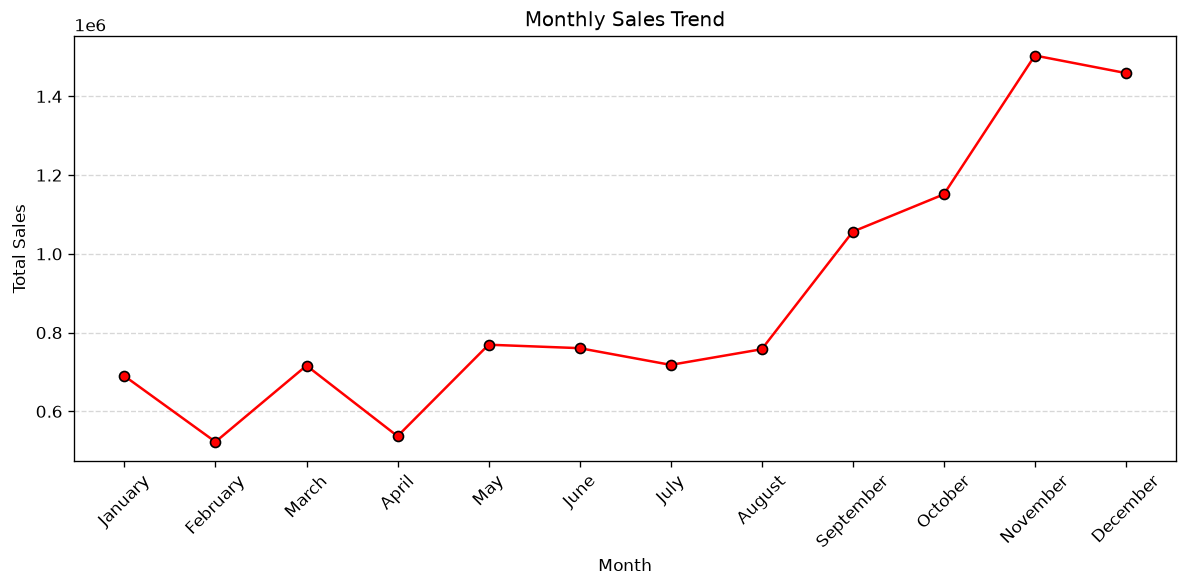

In [85]:
# Create and display the Monthly Sales Trend chart
monthly_sales = (
    df_sales.groupby(["Month", "MonthName"])["TotalSales"]
    .sum()
    .reset_index()
    .sort_values("Month")
)

plt.figure(figsize=(10,5),dpi=120, facecolor="white")

plt.plot(monthly_sales["MonthName"], monthly_sales["TotalSales"], color = "Red", marker="o",linestyle="-",markeredgecolor="black",markeredgewidth=1)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Business Insights

- November recorded the highest sales revenue among all months.
- December also showed strong sales, slightly lower than November.
- Sales increased steadily from September to November, indicating a strong growth trend.
- February and April recorded the lowest sales compared to other months.
- The sharp rise in sales during October, November, and December suggests increased customer demand during the holiday or festive season.

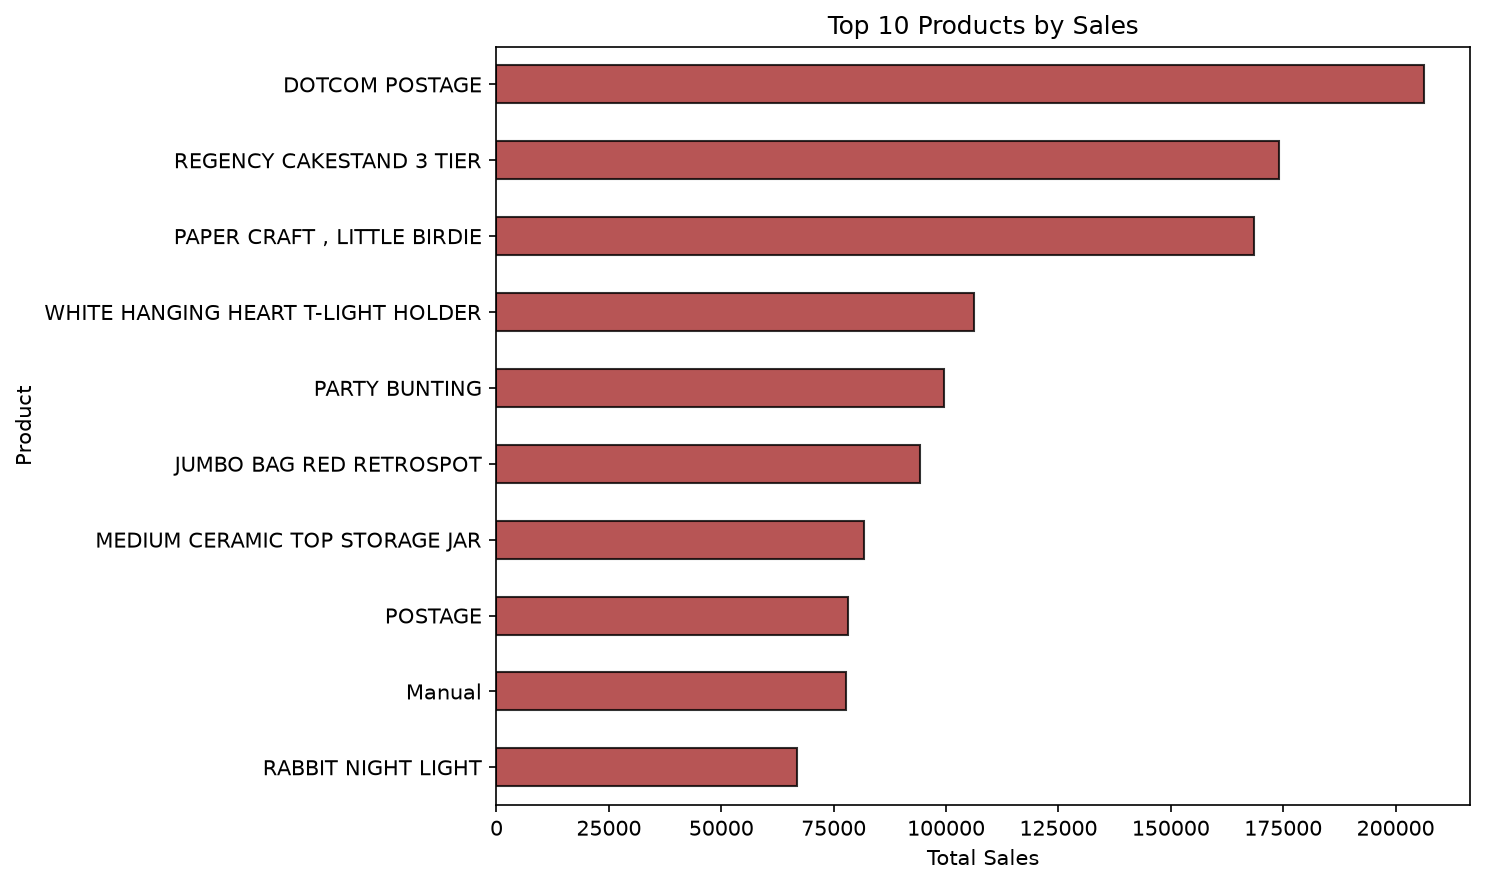

In [86]:
# Create and display a horizontal bar chart for Top 10 Products by Sales
top_products = (
    df_sales.groupby("Description")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6),dpi=150)

top_products.sort_values().plot(kind="barh", color = "Brown",edgecolor="black",alpha=0.8)

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

### Business Insights

- DOTCOM POSTAGE generated the highest sales revenue.
- REGENCY CAKESTAND 3 TIER and PAPER CRAFT, LITTLE BIRDIE were the next highest revenue-generating products.
- The top 10 products contributed significantly to total sales.
- High-performing products should be prioritized for inventory planning.

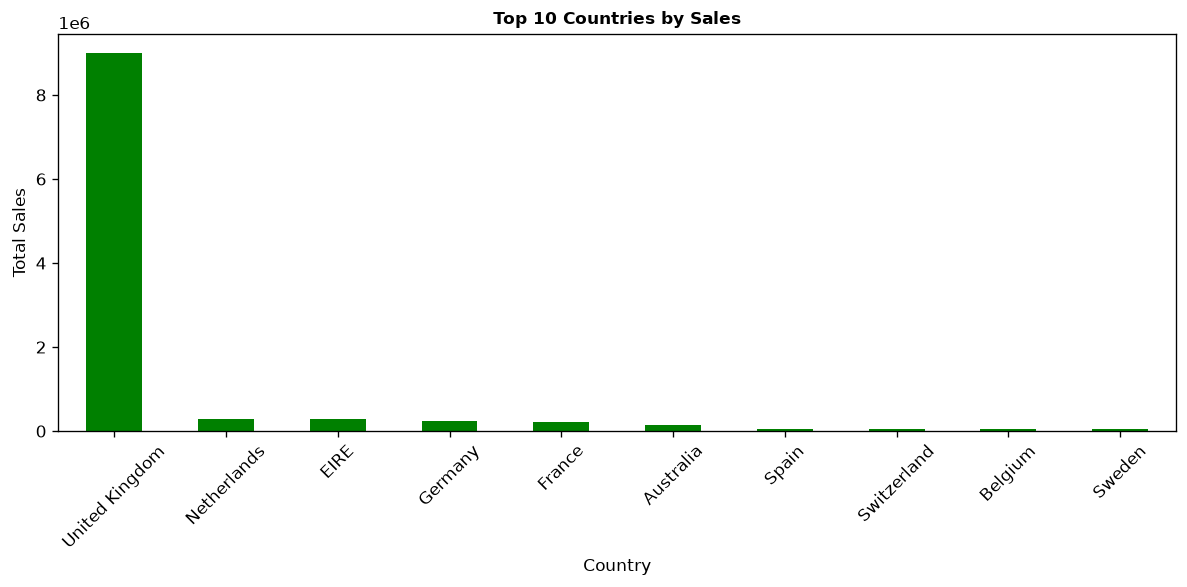

In [87]:
# Create and display a bar chart for Top 10 Countries by Sales
top_countries = (
    df_sales.groupby("Country")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5),dpi=120)

top_countries.plot(kind="bar", color = "green")

plt.title("Top 10 Countries by Sales",fontsize=10, fontweight="bold")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Business Insights

- United Kingdom generated the highest sales revenue by a significant margin.
- Netherlands and EIRE were the second and third highest revenue-generating countries.
- Germany, France, and Australia also contributed to overall sales but at a much lower level than the United Kingdom.
- The majority of total revenue came from the United Kingdom, indicating that it is the company's primary market.
- Expanding business in other high-performing countries could help increase overall sales and reduce dependence on a single market.

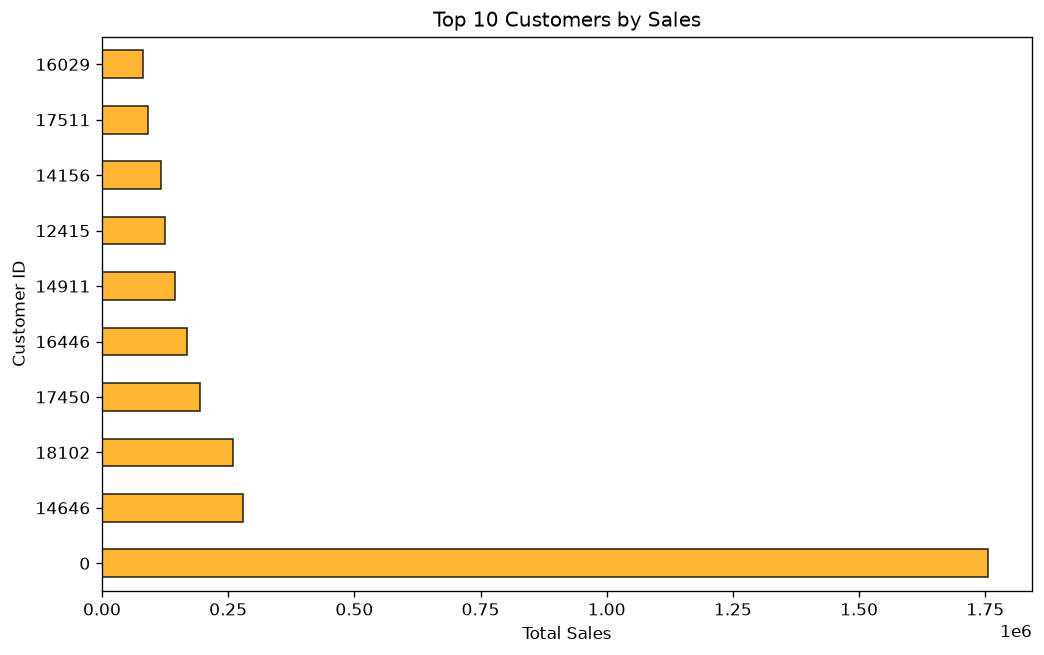

In [88]:
# Create and display a horizontal bar chart for Top 10 Customers by Sales
top_customers = (
    df_sales.groupby("CustomerID")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers.index = top_customers.index.astype(int)

plt.figure(figsize=(10,6),dpi=120)

top_customers.plot(kind="barh",color = "orange", edgecolor="black",alpha=0.8)
plt.title("Top 10 Customers by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Customer ID")
plt.show()

### Business Insights

- Customer ID 14646 generated the highest sales revenue among all customers.
- Customer ID 18102 was the second highest revenue-generating customer.
- The top 10 customers contributed a significant share of the total sales revenue.
- A small group of customers generated much higher revenue than the remaining customers.
- Retaining high-value customers through loyalty programs and personalized offers can help increase future sales.

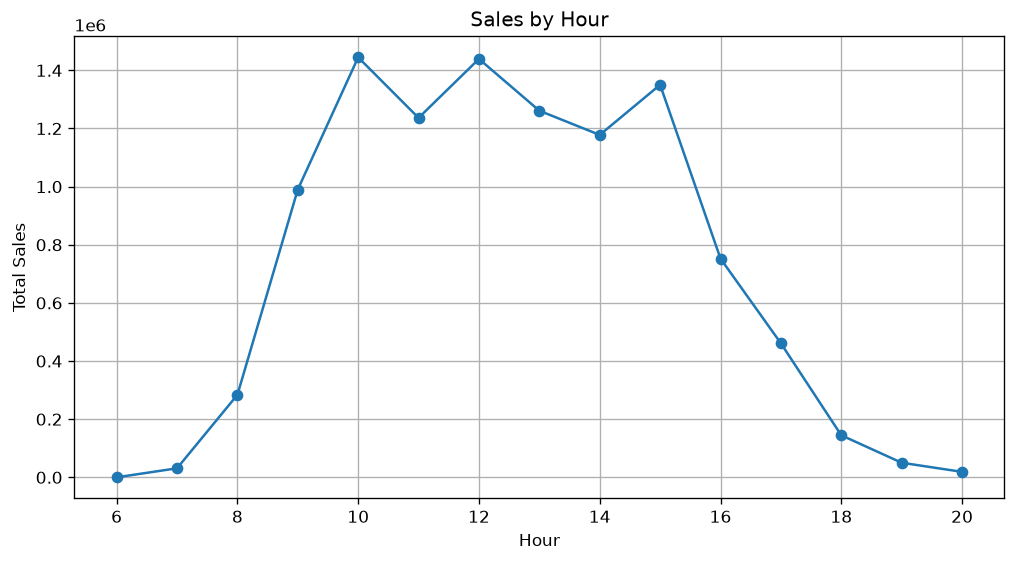

In [89]:
# Create and display a trend chart for Sales by Hour
sales_by_hour = (
    df_sales.groupby("Hour")["TotalSales"]
    .sum()
)

plt.figure(figsize=(10,5),dpi = 120)

plt.plot(sales_by_hour.index, sales_by_hour.values, marker="o")

plt.title("Sales by Hour")
plt.xlabel("Hour")
plt.ylabel("Total Sales")

plt.grid(True)

plt.show()

### Business Insights

- Sales started increasing rapidly from 9:00 AM onwards.
- The highest sales were recorded around 10:00 AM and 12:00 PM.
- Sales remained consistently high between 10:00 AM and 3:00 PM.
- After 4:00 PM, sales declined significantly.
- Business operations and promotional campaigns should be focused during peak shopping hours (10:00 AM – 3:00 PM) to maximize revenue.

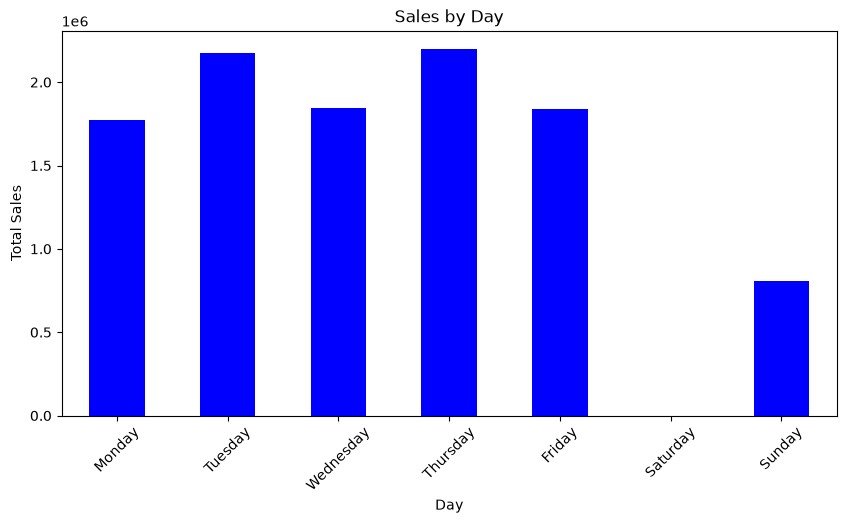

In [90]:
# Create and display a bar chart for Sales by Day of the week
sales_by_day = (
    df_sales.groupby("DayName")["TotalSales"]
    .sum()
)

days = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

sales_by_day = sales_by_day.reindex(days)

plt.figure(figsize=(10,5))

sales_by_day.plot(kind="bar", color = "Blue")

plt.title("Sales by Day")
plt.xlabel("Day")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

### Business Insights

- Thursday recorded the highest sales revenue among all days of the week.
- Tuesday was the second highest revenue-generating day.
- Monday, Wednesday, and Friday showed relatively consistent sales performance.
- Sunday recorded significantly lower sales compared to weekdays.
- No sales were recorded on Saturday, indicating that the business was likely closed or no transactions were made on that day.

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64


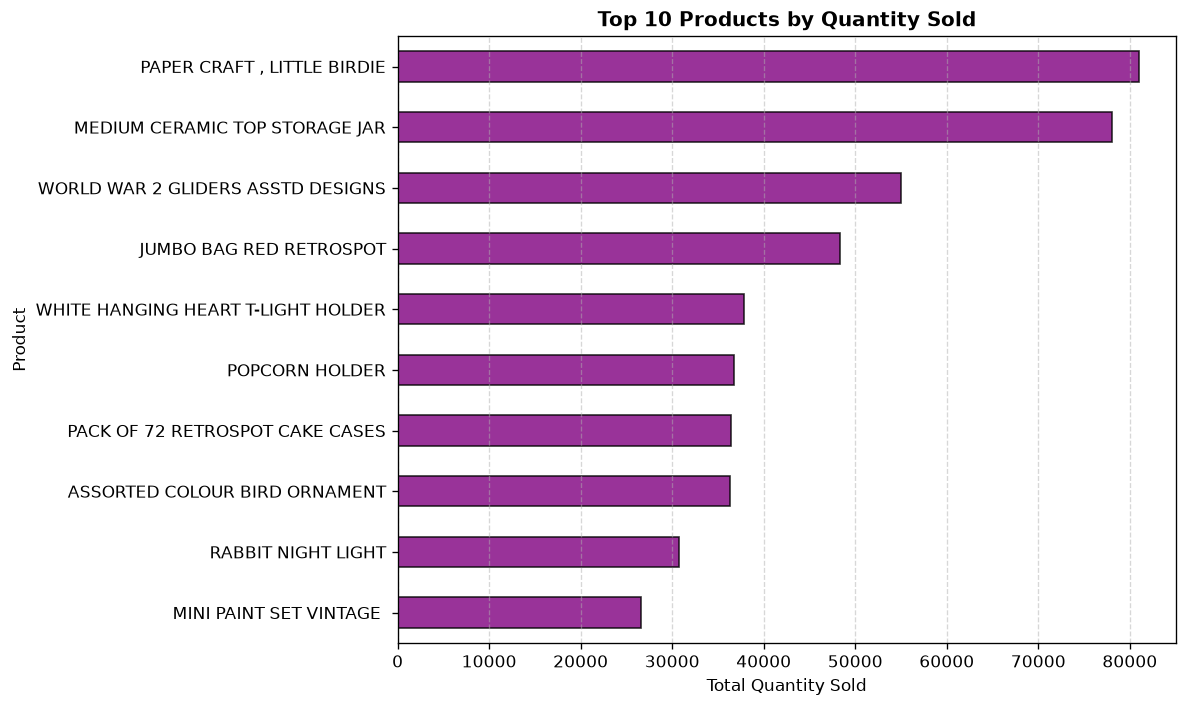

In [91]:
# Calculate the top 10 products by quantity sold
top_products_qty = (
    df_sales.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products_qty)

# Create and display a horizontal bar chart for Top 10 Products by Quantity Sold

plt.figure(figsize=(10,6), dpi=120)

top_products_qty[::-1].plot(
    kind="barh",
    color="purple",
    edgecolor="black",
    alpha=0.8
)

plt.title("Top 10 Products by Quantity Sold", fontsize=12, fontweight="bold")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()

plt.show()

### Business Insights

- PAPER CRAFT , LITTLE BIRDIE recorded the highest quantity sold with 80,995 units.
- MEDIUM CERAMIC TOP STORAGE JAR and WORLD WAR 2 GLIDERS ASSTD DESIGNS were the second and third most sold products.
- The top 10 products accounted for a significant share of the total quantity sold.
- These high-demand products should be prioritized for inventory planning to avoid stock shortages.
- Promoting these best-selling products through marketing campaigns and bundle offers can further improve overall sales.

# Conclusion

This project analyzed an online retail sales dataset using **Python, Pandas, and Matplotlib** to identify sales trends, customer behavior, and business insights.

## Key Findings

- The business generated **10.64 million** in revenue from **19,960 orders**, **4,338 customers**, and **3,922 products** across **38 countries**.
- The **United Kingdom** was the top revenue-generating country.
- **November** recorded the highest sales, followed by **December**, showing strong year-end demand.
- **DOTCOM POSTAGE** generated the highest revenue, followed by **REGENCY CAKESTAND 3 TIER** and **PAPER CRAFT, LITTLE BIRDIE**.
- **PAPER CRAFT, LITTLE BIRDIE** was the highest-selling product with **80,995 units**, followed by **MEDIUM CERAMIC TOP STORAGE JAR** and **WORLD      WAR 2 GLIDERS ASSTD DESIGNS**.
- Top-performing products contributed significantly to sales, highlighting the need for proper inventory management.
- A small group of customers generated a large share of revenue, showing the importance of customer retention strategies.
- Sales were highest between **10:00 AM and 3:00 PM**, making it the peak shopping period.
- **Thursday** recorded the highest sales, while **Sunday** had the lowest sales among weekdays.

## Final Remark

This analysis helps businesses improve inventory planning, retain valuable customers, optimize marketing strategies, and make better data-driven decisions.

In [92]:
# Export the cleaned dataset
df_sales.to_csv("online_retail_cleaned.csv", index=False)